Prediciton that $v_k(\tau)=\sin(k)$ is mode I want

In [1]:
import sys
sys.path.append("../../src/")
from project_imports import *

In [48]:
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

mp.mp.dps = 120  # precision

# ============================================================
# Your block (REPEATED EXACTLY)
# ============================================================

def v_tilde(tau, q, t):
    """Eq. 7.2.88"""
    a = 1 + mp.cos(q)
    b = mp.sin(q)

    rot = mp.e**(-1j * 3 * mp.pi / 4)
    rot_inv = mp.e**(1j * 3 * mp.pi / 4)
    decay = mp.e**(-mp.pi * b * b * tau / 4)
    prefactor = -decay
    argument = rot_inv * 2 * (t - a * tau) / mp.sqrt(tau)
    nu = 1j * b * b * tau

    with mp.workdps(mp.mp.dps + 10):
        return prefactor * mp.pcfd(nu, argument)

# ============================================================
# Parameters
# ============================================================

taus = np.logspace(-2, 4, 1000)
k_values = []

# ============================================================
# Find k minimizing |sin(k) - |v_tilde|| 
# ============================================================

for tau in taus:

    def objective(k):
        val = abs(v_tilde(tau, k, tau))
        return abs(np.sin(k) - float(val))

    result = minimize_scalar(
    objective,
    bounds=(pi/2, pi),
    method='bounded',
    options={'xatol': 1e-10}
    )    
    k_values.append(result.x)


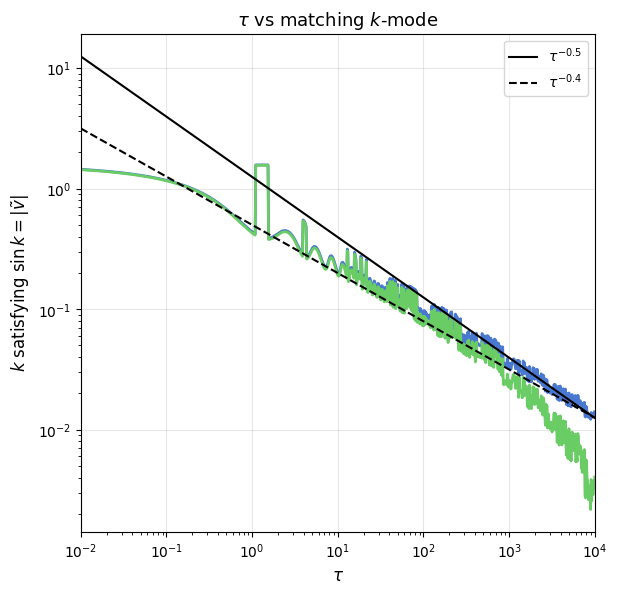

In [165]:

# ============================================================
# Plot
# ============================================================
k_values=array(k_values)
plt.figure(figsize=(6,6))
plt.plot(taus, pi-k_values, linewidth=2)
plt.plot(taus, pi-k_values-.01, linewidth=2)

plot(taus,taus**(-1/(2))/.8,color="black",label=r"$\tau^{-0.5}$")
plot(taus,taus**(-1/(2.5))/2,color="black",ls="--",label=r"$\tau^{-0.4}$")

plt.xlabel(r'$\tau$', fontsize=12)
plt.ylabel(r'$k$ satisfying $\sin k = |\tilde v|$', fontsize=12)
plt.title(r'$\tau$ vs matching $k$-mode', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
xlim(taus[0],taus[-1])
loglog()
legend()
plt.show()

Now, will these modes actually generate DQPT?


In [56]:
import numerical_quenches as nq

In [182]:
j= 720
g0= 30
k, tau = k_values[j],taus[j]
k=k+.05
g = nq.g_linear_hold
args=(tau,tau)
t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,2), np.linspace(tau+.0001,tau+pi,1000)))

u,v=nq.evolve_mode(k,g,t_eval,0,-1j,args)

Text(0.5, 1.0, '$\\tau=211.02034285685966, k=3.0969578234213695$')

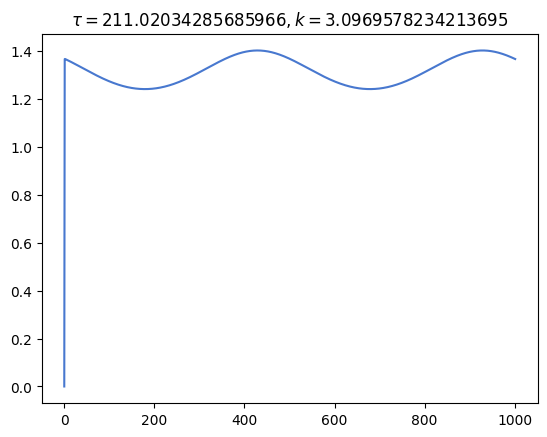

In [183]:
plot(-log(np.abs(np.conj(u[0])*u+np.conj(v[0])*v)))
title(rf"$\tau={tau}, k={k}$")

g0=5.0


Text(0.5, 1.0, '2.525820026962785')

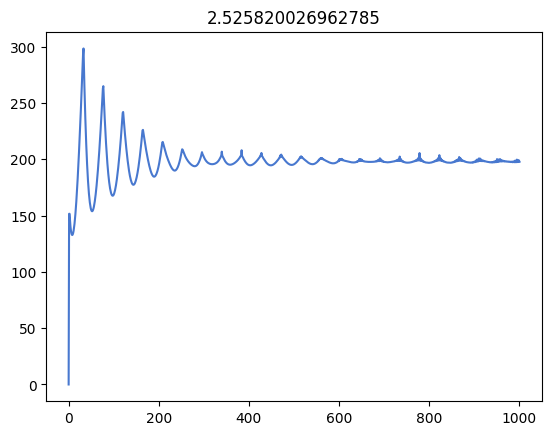

In [244]:
j= 400
g0= 5
k, tau = k_values[j],taus[j]
k=k+.05
g = nq.g_linear_hold
args=(tau,tau-tau/2)
t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,2), np.linspace(tau+.0001,tau+20*pi,1000)))

states=nq.states(1000,t_eval,g,args)
plot(-log(nq.overlap(states,states[0])))
title(tau)

(0.0, 0.5)

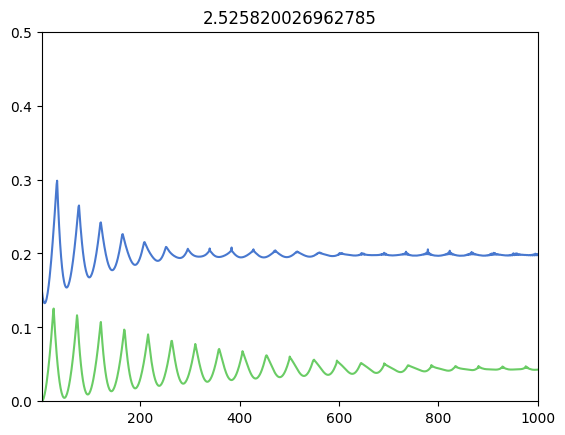

In [246]:
plot(-log(nq.overlap(states,states[0]))/1000)
plot(-log(nq.overlap(states,states[1]))/1000)

title(tau)
xlim(2,1000)
ylim(0,.5)


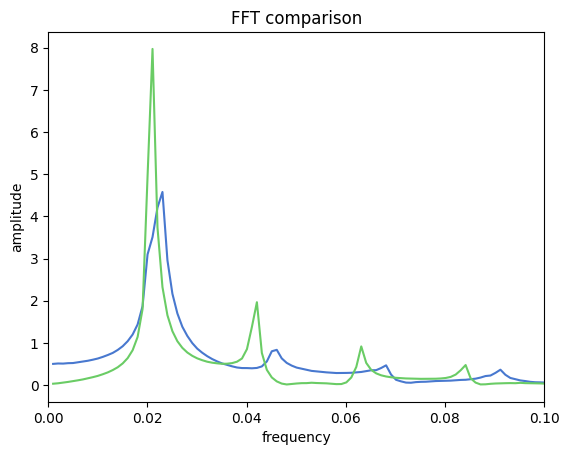

In [247]:
import numpy as np
import matplotlib.pyplot as plt

# --- original signals ---
y0 = -np.log(nq.overlap(states, states[0])) / 1000
y1 = -np.log(nq.overlap(states, states[1])) / 1000

# optional: restrict to same window you plotted
start, stop = 2, 1000
y0 = y0[start:stop]
y1 = y1[start:stop]

N = len(y0)

# remove DC component (important for FFT comparison)
y0 = y0 - np.mean(y0)
y1 = y1 - np.mean(y1)

# --- FFT ---
fft0 = np.fft.fft(y0)
fft1 = np.fft.fft(y1)

freq = np.fft.fftfreq(N, d=1)   # change d if tau spacing ≠ 1

# take positive frequencies
mask = freq > 0
freq = freq[mask]
amp0 = np.abs(fft0[mask])
amp1 = np.abs(fft1[mask])

# --- Plot comparison ---
plt.figure()
plt.plot(freq, amp0)
plt.plot(freq, amp1)
plt.xlim(0, 0.1)   # adjust as needed
plt.xlabel("frequency")
plt.ylabel("amplitude")
plt.title("FFT comparison")
plt.show()

In [290]:
from scipy.linalg import expm

In [299]:
x,y= 1/2,1/2
Delta= 1
t_eval= linspace(0,10,100)
psi0=array([x,y])
H= array([[0,Delta],[Delta,0]])
psi_t = array([expm(1j*H*ti)@psi0 for ti in t_eval])



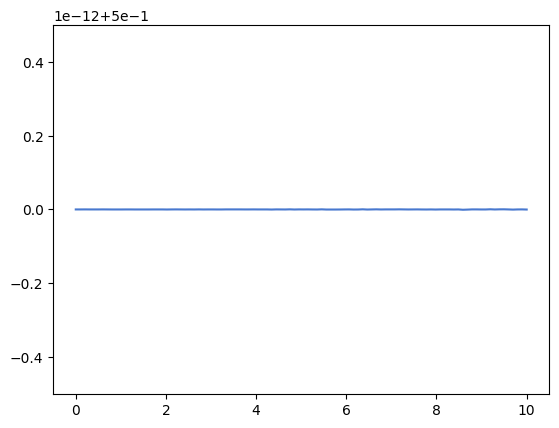

In [300]:
plot(t_eval,np.abs(psi_t[:,0]))

In [282]:
psi_t[0]

array([1.41421356+0.j, 1.41421356+0.j])

In [270]:
psi_t[0]

array([1.41421356+0.j, 1.41421356+0.j])